# 🛒 Retail Sales Analysis
## Notebook 4 — Customer Segmentation (K-Means)

**Цель:** сегментировать клиентов на группы по их поведению с помощью алгоритма K-Means, интерпретировать сегменты и дать бизнес-рекомендации.

---
## 1. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style='whitegrid')

print('✅ Библиотеки загружены')

✅ Библиотеки загружены


In [2]:
customers_features = pd.read_csv('customers_features.csv')

print(f'customers_features: {customers_features.shape}')
display(customers_features.head())

customers_features: (98759, 8)


,customer_id,total_spent,avg_check,num_checks,total_items,avg_items_per_check,avg_unique_products,recency
0,1,3135.080,49.763,63,63,1.000,1.000,4
1,2,3355.045,53.255,63,63,1.000,1.000,6
2,3,3318.653,47.409,70,70,1.000,1.000,1
3,4,3122.561,45.255,69,69,1.000,1.000,2
4,5,2650.345,44.921,59,59,1.000,1.000,1


---
## 2. Подготовка признаков

In [3]:
FEATURE_COLS = [
    'total_spent', 'avg_check', 'num_checks',
    'total_items', 'avg_items_per_check', 'recency'
]

features = customers_features[FEATURE_COLS].copy()

print('Пропуски в признаках:')
print(features.isnull().sum())
features = features.fillna(0)
print('\nПосле fillna(0):', features.isnull().sum().sum(), 'пропусков')

Пропуски в признаках:
total_spent            0
avg_check              0
num_checks             0
total_items            0
avg_items_per_check    0
recency                0
dtype: int64

После fillna(0): 0 пропусков


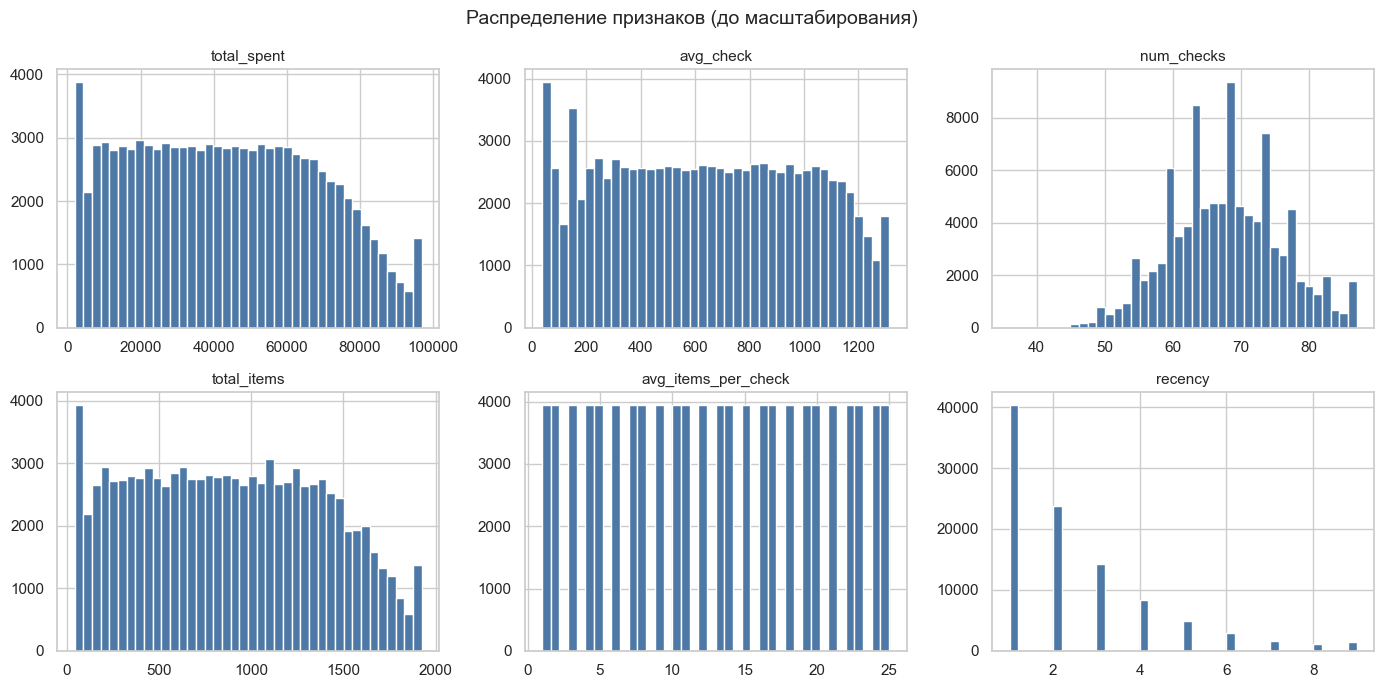

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, FEATURE_COLS):
    ax.hist(features[col].clip(upper=features[col].quantile(0.99)), bins=40,
            color='#4e79a7', edgecolor='white')
    ax.set_title(col, fontsize=11)
fig.suptitle('Распределение признаков (до масштабирования)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Масштабирование признаков

In [5]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

features_scaled_df = pd.DataFrame(features_scaled, columns=FEATURE_COLS)
print('✅ Масштабирование выполнено')
display(features_scaled_df.describe())

✅ Масштабирование выполнено


,total_spent,avg_check,num_checks,total_items,avg_items_per_check,recency
count,98759.000,98759.000,98759.000,98759.000,98759.000,98759.000
mean,-0.000,-0.000,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.655,-1.681,-3.867,-1.665,-1.664,-0.768
25%,-0.852,-0.864,-0.700,-0.859,-0.832,-0.768
50%,-0.035,-0.009,0.031,-0.024,-0.000,-0.238
75%,0.787,0.844,0.640,0.808,0.832,0.292
max,3.317,2.648,4.173,3.062,1.664,10.366


---
## 4. Elbow Method + Silhouette Score — выбор числа кластеров

k=2  inertia=304,073.0  silhouette=0.4088
k=3  inertia=249,149.7  silhouette=0.2892
k=4  inertia=210,758.9  silhouette=0.3038
k=5  inertia=184,181.1  silhouette=0.2722
k=6  inertia=162,905.8  silhouette=0.2574
k=7  inertia=145,893.5  silhouette=0.2714
k=8  inertia=130,405.2  silhouette=0.2682
k=9  inertia=121,463.5  silhouette=0.2581


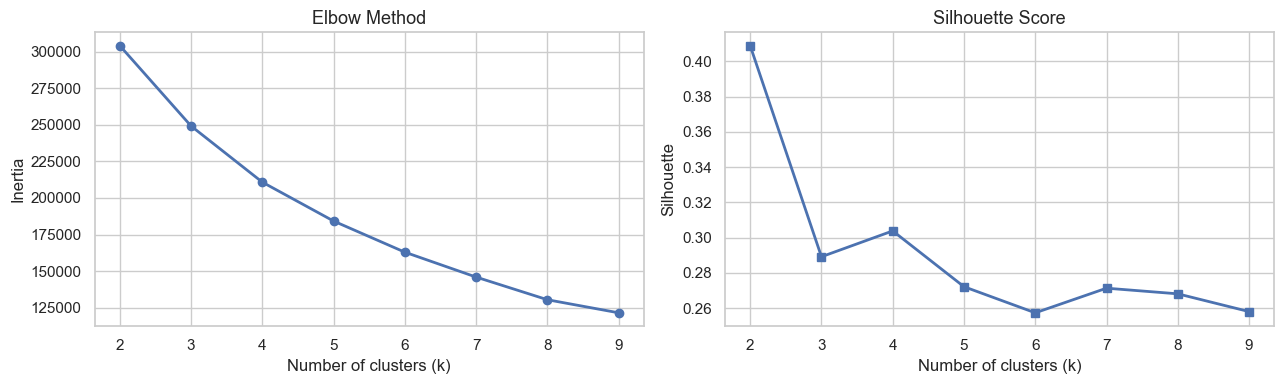

In [7]:
inertia = []
silhouette = []
K_RANGE = range(2, 10)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)

    inertia.append(km.inertia_)
    silhouette.append(
        silhouette_score(features_scaled, labels, sample_size=10000, random_state=42)
    )

    print(f'k={k}  inertia={km.inertia_:,.1f}  silhouette={silhouette[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_RANGE), inertia, marker='o', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=13)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_RANGE), silhouette, marker='s', linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=13)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.show()

Для выбора количества кластеров были использованы Elbow Method и Silhouette Score.

Silhouette Score максимален при k=2 (0.41), что говорит о хорошем разделении на 2 кластера.

Однако Elbow Method показывает "излом" в районе k=3–4. Поэтому для более детальной сегментации клиентов было выбрано k=4, что позволяет выделить несколько типов поведения клиентов.

---
## 5. Обучение K-Means

> Выбираем число кластеров по "локтю" на графике Elbow и максимуму Silhouette Score.

In [8]:
N_CLUSTERS = 4 

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
customers_features['cluster'] = kmeans.fit_predict(features_scaled)

print(f'✅ K-Means обучен  (k={N_CLUSTERS})')
print('\nРаспределение по кластерам:')
display(customers_features['cluster'].value_counts().sort_index().rename('Клиентов'))

✅ K-Means обучен  (k=4)

Распределение по кластерам:


cluster
0    29631
1     7993
2    31576
3    29559
Name: Клиентов, dtype: int64

---
## 6. Средние значения по кластерам

In [9]:
cluster_summary = (
    customers_features
    .groupby('cluster')[FEATURE_COLS]
    .mean()
    .round(2)
)

cluster_summary['size'] = customers_features['cluster'].value_counts().sort_index()

print('📊 Средние значения по кластерам:')
display(cluster_summary)

📊 Средние значения по кластерам:


,total_spent,avg_check,num_checks,total_items,avg_items_per_check,recency,size
cluster,,,,,,,
0,43553.520,652.330,67.360,887.650,13.300,1.840,29631
1,42904.380,681.270,63.330,872.360,13.850,6.860,7993
2,15301.170,228.100,67.440,311.790,4.650,2.210,31576
3,73501.240,1059.590,69.660,1484.620,21.400,2.120,29559


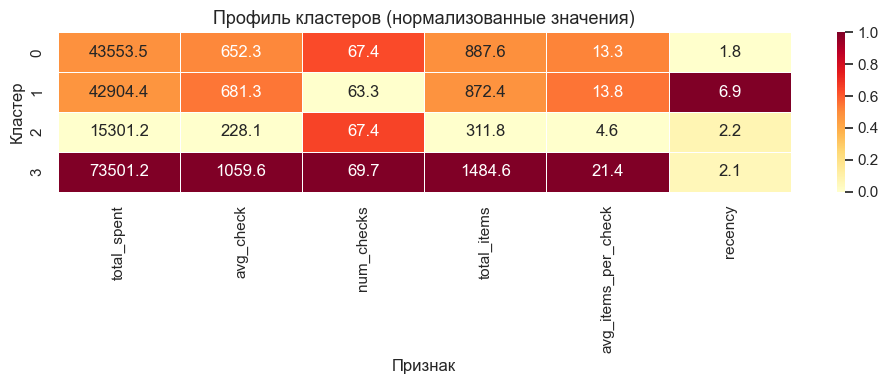

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
norm_summary = cluster_summary[FEATURE_COLS].apply(
    lambda col: (col - col.min()) / (col.max() - col.min() + 1e-9)
)
sns.heatmap(norm_summary, annot=cluster_summary[FEATURE_COLS].round(1),
            fmt='g', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Профиль кластеров (нормализованные значения)', fontsize=13)
ax.set_xlabel('Признак')
ax.set_ylabel('Кластер')
plt.tight_layout()
plt.show()

In [ ]:
cs = cluster_summary[FEATURE_COLS].copy()

print('Помощь для интерпретации:')
print('  total_spent  ↑ = больше потратил')
print('  avg_check    ↑ = выше средний чек')
print('  num_checks   ↑ = чаще покупает')
print('  recency      ↓ = недавно покупал (активен)')
print()
display(cs)

Помощь для интерпретации:
  total_spent  ↑ = больше потратил
  avg_check    ↑ = выше средний чек
  num_checks   ↑ = чаще покупает
  recency      ↓ = недавно покупал (активен)



,total_spent,avg_check,num_checks,total_items,avg_items_per_check,recency
cluster,,,,,,
0,43553.520,652.330,67.360,887.650,13.300,1.840
1,42904.380,681.270,63.330,872.360,13.850,6.860
2,15301.170,228.100,67.440,311.790,4.650,2.210
3,73501.240,1059.590,69.660,1484.620,21.400,2.120


In [15]:
cluster_names = {
    0: 'Regular customers',
    1: 'At-risk customers',
    2: 'Low value customers',
    3: 'VIP customers'
}

customers_features['segment_name'] = customers_features['cluster'].map(cluster_names)

print('Распределение по сегментам:')
display(
    customers_features['segment_name']
    .value_counts()
    .rename('Клиентов')
    .reset_index(name='Клиентов')
)

Распределение по сегментам:


,segment_name,Клиентов
0,Low value customers,31576
1,Regular customers,29631
2,VIP customers,29559
3,At-risk customers,7993


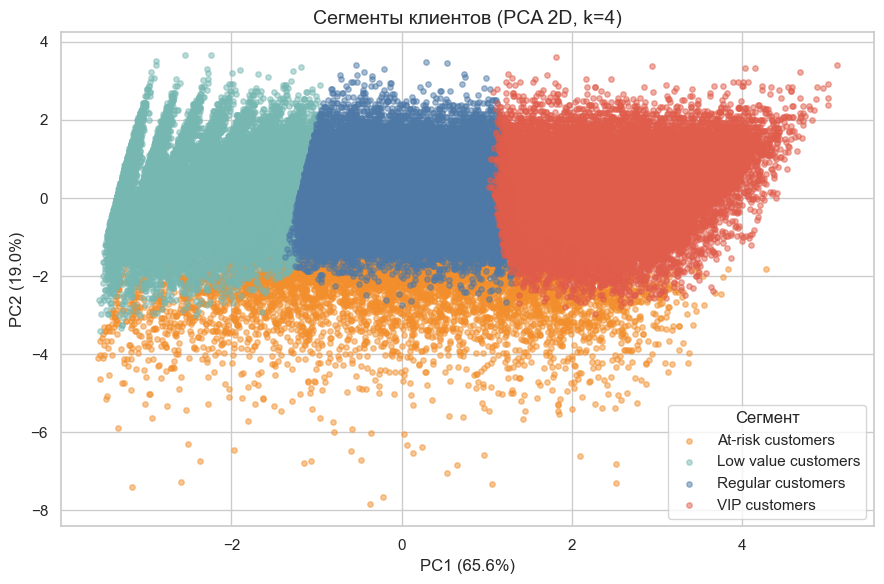

In [ ]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(features_scaled)

pca_df = pd.DataFrame(
    coords, columns=['PC1', 'PC2']
)
pca_df['segment'] = customers_features['segment_name'].values

palette = {
    'VIP customers':          '#e05c4b',
    'Regular customers':      '#4e79a7',
    'Low value customers': '#76b7b2',
    'At-risk customers':      '#f28e2b'
}

fig, ax = plt.subplots(figsize=(9, 6))
for seg, grp in pca_df.groupby('segment'):
    ax.scatter(grp['PC1'], grp['PC2'], label=seg,
               s=15, alpha=0.5, color=palette.get(seg, 'grey'))
ax.set_title(f'Сегменты клиентов (PCA 2D, k={N_CLUSTERS})', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(title='Сегмент', loc='best')
plt.tight_layout()
plt.show()

In [ ]:
seg_stats = customers_features.groupby('segment_name')[FEATURE_COLS].mean().round(2)
seg_stats['count'] = customers_features['segment_name'].value_counts()
display(seg_stats)

,total_spent,avg_check,num_checks,total_items,avg_items_per_check,recency,count
segment_name,,,,,,,
At-risk customers,42904.380,681.270,63.330,872.360,13.850,6.860,7993
Low value customers,15301.170,228.100,67.440,311.790,4.650,2.210,31576
Regular customers,43553.520,652.330,67.360,887.650,13.300,1.840,29631
VIP customers,73501.240,1059.590,69.660,1484.620,21.400,2.120,29559


---
## 8. Бизнес-рекомендации по сегментам

| Сегмент | Характеристика | Рекомендация |
|---------|---------------|--------------|
| **VIP customers** | Высокий `total_spent`, низкий `recency` | Персональные предложения, приоритетный сервис, программа лояльности |
| **Regular customers** | Средние показатели, стабильная активность | Стимулировать увеличение среднего чека: upsell, cross-sell, бандлы |
| **Low activity customers** | Низкий `total_spent` и `num_checks` | Welcome-офферы, скидки на первый повторный заказ, email-кампании |
| **At-risk customers** | Высокий `recency` (давно не покупали) | Реактивационные кампании: «Мы скучаем», спецпредложения с ограниченным сроком |

---
## 9. Сохранение результатов

In [18]:
customers_features.to_csv('customer_segments.csv', index=False)
cluster_summary.to_csv('cluster_summary.csv')

print('✅ Сохранены:')
print('  customer_segments.csv  — клиенты с кластером и названием сегмента')
print('  cluster_summary.csv    — средние значения признаков по кластерам')

✅ Сохранены:
  customer_segments.csv  — клиенты с кластером и названием сегмента
  cluster_summary.csv    — средние значения признаков по кластерам


---
## 📝 Выводы по Notebook 4

- Методом **K-Means** клиенты разбиты на **4 сегмента**.
- Выбор числа кластеров обоснован методом локтя и коэффициентом силуэта.
- Каждый сегмент интерпретирован по среднему профилю признаков.
- Для каждого сегмента сформулированы бизнес-рекомендации.

